# zz3 — database comparison for non-human-antigen TCR removal (reviewer comment 3.3)

Would adding **McPAS-TCR** and/or **IEDB** to the VDJdb-based *non-human antigen* removal
step (`zz2_construct_training_data.Rmd`) change the cancer-reactive (CR) TCR set?

This notebook mirrors the VDJdb filter **without modifying the pipeline**. For each cell with
a paired α/β TCR, each chain is matched against a database of human TCRs recognizing a
non-human (microbial/viral) antigen; a cell is flagged for removal only if **both** chains
match (the zz2 rule `non_human_antigen == "Both"`).

All sources are normalized identically (V gene: `TCR→TR`, drop allele/list tail; CDR3: drop
conserved leading `C` / trailing `F`,`W`). Two match modes: **exact** (CDR3 core + V gene,
faithful to the pipeline) and **cdr3** (CDR3-only, a lenient upper bound).

In [1]:
import os, io, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

HOME   = os.path.expanduser("~")
CR_DIR = f"{HOME}/research/CAT/data"
VDJDB  = f"{HOME}/research/GitHub/cancer_reactive_TCR/data_VDJdb/vdjdb-2025-02-21/vdjdb.slim.txt"
MCPAS  = f"{HOME}/research/GitHub/cancer_reactive_TCR/data_McPAS/McPAS-TCR.csv.gz"
IEDB   = f"{HOME}/research/GitHub/cancer_reactive_TCR/data_IEDB/tcr_full_v3.zip"
OUTDIR = f"{HOME}/research/CAT/_revision/db_comparison"
os.makedirs(OUTDIR, exist_ok=True)

CLONO = ["TRA_cdr3", "TRA_v_gene", "TRB_cdr3", "TRB_v_gene"]

## Normalization helpers

In [2]:
def norm_v(s):
    if pd.isna(s): return ""
    s = str(s).replace("\xa0", "").strip().upper().replace("TCR", "TR")
    s = s.split(",")[0]            # first gene of a list
    s = s.split("*")[0]            # drop allele
    return s.strip()

def norm_cdr3(s):
    if pd.isna(s): return ""
    s = str(s).replace("\xa0", "").strip().upper()
    if not s or not s.isalpha(): return s if s else ""
    if s.startswith("C"): s = s[1:]
    if s.endswith(("F", "W")): s = s[:-1]
    return s

def prep_db(alpha, beta):
    """alpha/beta: DataFrames with raw columns ['cdr3','v_gene']; normalize + dedup."""
    out = []
    for d in (alpha, beta):
        d = d.copy()
        d["cdr3"]   = d["cdr3"].map(norm_cdr3)
        d["v_gene"] = d["v_gene"].map(norm_v)
        d = d[d["cdr3"] != ""]
        out.append(d.drop_duplicates())
    return out

## Load the cancer-reactive cells (paired-TCR)

In [3]:
def load_cr(cell_type):
    df = pd.read_csv(f"{CR_DIR}/{cell_type}_combined.tsv.gz", sep="\t", low_memory=False)
    for c in CLONO:
        df[c] = df[c].fillna("").astype(str)
    df = df[(df["TRA_cdr3"] != "") & (df["TRB_cdr3"] != "")].copy()
    df["cancer_reactive"] = (df["cancer_reactive_per_cell"].astype(bool)
                             & df["study_specific_CR_by_cluster"].astype(bool))
    df["a_cdr3"] = df["TRA_cdr3"].map(norm_cdr3); df["a_v"] = df["TRA_v_gene"].map(norm_v)
    df["b_cdr3"] = df["TRB_cdr3"].map(norm_cdr3); df["b_v"] = df["TRB_v_gene"].map(norm_v)
    return df

## Database loaders — human TCRs recognizing a non-human antigen
- **VDJdb**: host = HomoSapiens, score ≥ 2, antigen.species ≠ HomoSapiens
- **McPAS**: Species = Human, Category = Pathogens
- **IEDB**: `Epitope / Source Organism` present and not *Homo sapiens*

In [4]:
def db_vdjdb():
    v = pd.read_csv(VDJDB, sep="\t", low_memory=False)
    v = v[(v["species"] == "HomoSapiens") & (v["vdjdb.score"] >= 2)].copy()
    v["v_gene"] = v["v.segm"]
    v = v[v["antigen.species"] != "HomoSapiens"]
    a = v[v["gene"] == "TRA"][["cdr3", "v_gene"]]
    b = v[v["gene"] == "TRB"][["cdr3", "v_gene"]]
    return prep_db(a, b)

def db_mcpas():
    m = pd.read_csv(MCPAS, encoding="latin-1", low_memory=False)
    m = m[(m["Species"] == "Human") & (m["Category"] == "Pathogens")]
    a = m[["CDR3.alpha.aa", "TRAV"]].rename(columns={"CDR3.alpha.aa": "cdr3", "TRAV": "v_gene"})
    b = m[["CDR3.beta.aa",  "TRBV"]].rename(columns={"CDR3.beta.aa":  "cdr3", "TRBV": "v_gene"})
    return prep_db(a, b)

def db_iedb():
    with zipfile.ZipFile(IEDB) as z:
        name = [n for n in z.namelist() if n.endswith(".csv")][0]
        df = pd.read_csv(io.BytesIO(z.read(name)), header=[0, 1], low_memory=False)
    df.columns = [" / ".join([str(x), str(y)]) for x, y in df.columns]
    C = df.columns; src = C[8]
    nonhuman = df[src].notna() & (~df[src].astype(str).str.startswith("Homo sapiens"))
    d = df[nonhuman]
    def pick(row, cur, calc):
        v = row[cur]
        return v if (pd.notna(v) and str(v).strip() != "") else row[calc]
    a = pd.DataFrame({"cdr3": d.apply(lambda r: pick(r, C[23], C[24]), axis=1),
                      "v_gene": d.apply(lambda r: pick(r, C[15], C[16]), axis=1)})
    b = pd.DataFrame({"cdr3": d.apply(lambda r: pick(r, C[54], C[55]), axis=1),
                      "v_gene": d.apply(lambda r: pick(r, C[46], C[47]), axis=1)})
    return prep_db(a, b)

## Matching helpers

In [5]:
def chain_hits(df, alpha, beta, mode):
    """(a_hit, b_hit): does each chain match the database?"""
    if mode == "exact":
        ak = set(zip(alpha["cdr3"], alpha["v_gene"])); bk = set(zip(beta["cdr3"], beta["v_gene"]))
        a_hit = df.apply(lambda r: (r["a_cdr3"], r["a_v"]) in ak, axis=1)
        b_hit = df.apply(lambda r: (r["b_cdr3"], r["b_v"]) in bk, axis=1)
    else:
        ak = set(alpha["cdr3"]); bk = set(beta["cdr3"])
        a_hit = df["a_cdr3"].isin(ak); b_hit = df["b_cdr3"].isin(bk)
    return a_hit.to_numpy(), b_hit.to_numpy()

def flag_both(df, alpha, beta, mode):
    a_hit, b_hit = chain_hits(df, alpha, beta, mode)
    return a_hit & b_hit

def nonhuman_category(a_hit, b_hit):
    """Reproduce zz2 add_non_human_antigen(): Both / TRA / TRB / None."""
    cat = np.full(len(a_hit), "None", dtype=object)
    cat[a_hit & b_hit]  = "Both"
    cat[a_hit & ~b_hit] = "TRA"
    cat[~a_hit & b_hit] = "TRB"
    return cat

## Load the three databases

In [6]:
dbs = {"VDJdb": db_vdjdb(), "McPAS": db_mcpas(), "IEDB": db_iedb()}
for n, (a, b) in dbs.items():
    print(f"{n:7s}: {len(a):>7,} TRA  {len(b):>7,} TRB  normalized non-human entries")

VDJdb  :  24,724 TRA   36,286 TRB  normalized non-human entries
McPAS  :   6,610 TRA   24,682 TRB  normalized non-human entries
IEDB   :  48,665 TRA  168,207 TRB  normalized non-human entries


## Comparison — additional cancer-reactive cells removed *beyond VDJdb*

In [7]:
def run(cell_type, dbs):
    cr = load_cr(cell_type)
    crpos = cr["cancer_reactive"].to_numpy(); n_cr = int(crpos.sum())
    print(f"{cell_type}: {len(cr):,} paired-TCR cells, {n_cr:,} cancer-reactive")
    rows = []
    for mode in ("exact", "cdr3"):
        flags = {name: flag_both(cr, a, b, mode) for name, (a, b) in dbs.items()}
        vdj = flags["VDJdb"]
        for name, fl in flags.items():
            removed = int((fl & crpos).sum())
            add = int((fl & crpos & ~vdj).sum()) if name != "VDJdb" else 0
            rows.append({"cell_type": cell_type, "match_mode": mode, "database": name,
                         "n_cancer_reactive": n_cr, "CR_cells_removed": removed,
                         "pct_removed": round(100*removed/n_cr, 3),
                         "additional_vs_VDJdb": add,
                         "pct_additional": round(100*add/n_cr, 3)})
        union = vdj.copy()
        for fl in flags.values(): union = union | fl
        add_u = int((union & crpos & ~vdj).sum())
        rows.append({"cell_type": cell_type, "match_mode": mode, "database": "McPAS+IEDB union",
                     "n_cancer_reactive": n_cr, "CR_cells_removed": int((union & crpos).sum()),
                     "pct_removed": round(100*int((union & crpos).sum())/n_cr, 3),
                     "additional_vs_VDJdb": add_u, "pct_additional": round(100*add_u/n_cr, 3)})
    return rows

summary = pd.DataFrame(sum((run(ct, dbs) for ct in ["CD8", "CD4"]), []))
summary.to_csv(f"{OUTDIR}/db_comparison_summary.csv", index=False)
summary

CD8: 475,785 paired-TCR cells, 110,163 cancer-reactive
CD4: 497,076 paired-TCR cells, 69,696 cancer-reactive


,cell_type,match_mode,database,n_cancer_reactive,CR_cells_removed,pct_removed,additional_vs_VDJdb,pct_additional
0,CD8,exact,VDJdb,110163,179,0.162,0,0.000
1,CD8,exact,McPAS,110163,26,0.024,19,0.017
2,CD8,exact,IEDB,110163,220,0.200,113,0.103
3,CD8,exact,McPAS+IEDB union,110163,305,0.277,126,0.114
4,CD8,cdr3,VDJdb,110163,1084,0.984,0,0.000
5,CD8,cdr3,McPAS,110163,184,0.167,72,0.065
6,CD8,cdr3,IEDB,110163,1493,1.355,769,0.698
7,CD8,cdr3,McPAS+IEDB union,110163,1913,1.737,829,0.753
8,CD4,exact,VDJdb,69696,3,0.004,0,0.000
9,CD4,exact,McPAS,69696,2,0.003,2,0.003


## IEDB plot — proportion of cancer-reactive T cells by non-human-antigen category

Reproduces the `draw_bar_plot` panels from `zz2` (right before the *"Filter out cells whose TCR…"*
section), now using **IEDB** annotations. Cells whose **both** chains match a non-human antigen
(`Both`) should show the **lowest** cancer-reactive proportion — the rationale for removing them.

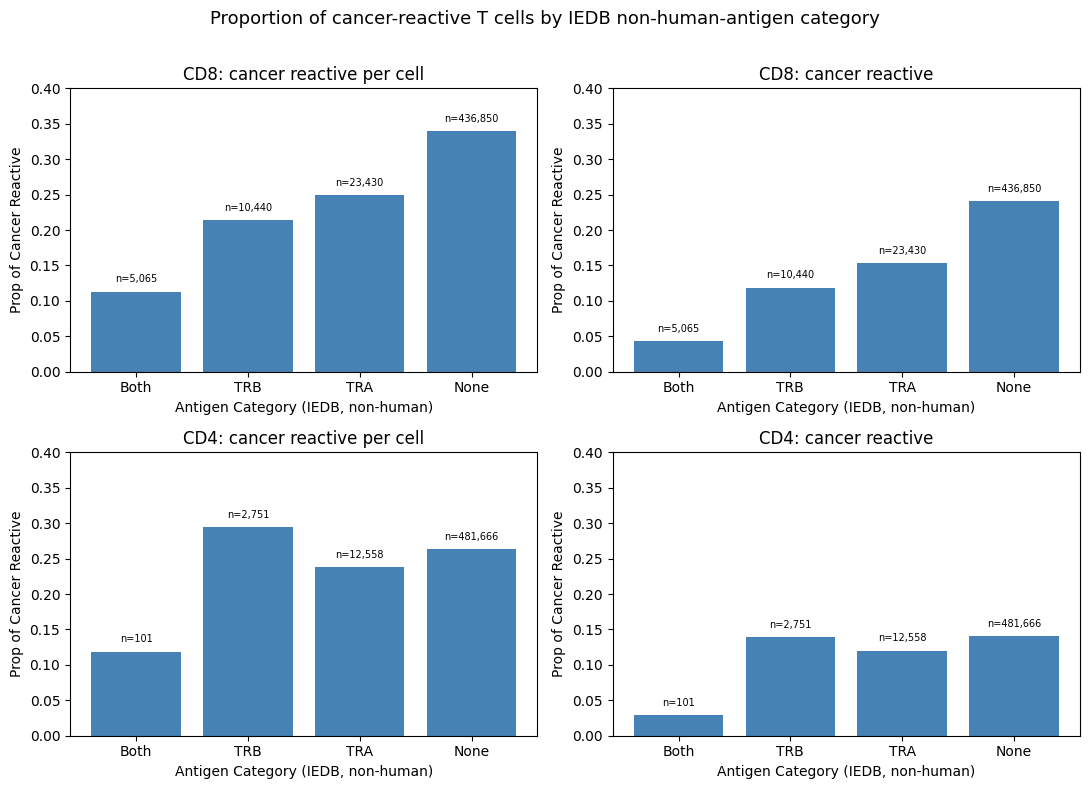

,cell_type,cr_definition,antigen_category,n_total,n_cancer_reactive,proportion_reactive
0,CD8,cancer_reactive_per_cell,Both,5065,573,0.1131
1,CD8,cancer_reactive_per_cell,TRB,10440,2239,0.2145
2,CD8,cancer_reactive_per_cell,TRA,23430,5839,0.2492
3,CD8,cancer_reactive_per_cell,None,436850,148197,0.3392
4,CD8,cancer_reactive,Both,5065,220,0.0434
5,CD8,cancer_reactive,TRB,10440,1241,0.1189
6,CD8,cancer_reactive,TRA,23430,3600,0.1536
7,CD8,cancer_reactive,None,436850,105102,0.2406
8,CD4,cancer_reactive_per_cell,Both,101,12,0.1188
9,CD4,cancer_reactive_per_cell,TRB,2751,810,0.2944


In [8]:
order   = ["Both", "TRB", "TRA", "None"]                      # same order as zz2
cr_cols = ["cancer_reactive_per_cell", "cancer_reactive"]
alpha, beta = dbs["IEDB"]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
prop_rows = []
for i, ct in enumerate(["CD8", "CD4"]):
    cr = load_cr(ct)
    cr["cancer_reactive_per_cell"] = cr["cancer_reactive_per_cell"].astype(bool)
    a_hit, b_hit = chain_hits(cr, alpha, beta, "exact")        # exact = pipeline-faithful
    cat = nonhuman_category(a_hit, b_hit)
    for j, col in enumerate(cr_cols):
        ax = axes[i, j]
        sub = pd.DataFrame({"cat": cat, "cr": cr[col].to_numpy().astype(bool)})
        grp = sub.groupby("cat")["cr"].agg(total="size", n_reactive="sum").reindex(order)
        grp["prop"] = grp["n_reactive"] / grp["total"]
        ax.bar(order, grp["prop"].values, color="steelblue")
        for x, (p, n) in enumerate(zip(grp["prop"].values, grp["total"].values)):
            if pd.notna(p):
                ax.text(x, p + 0.01, f"n={int(n):,}", ha="center", va="bottom", fontsize=7)
        ax.set_ylim(0, 0.4)
        ax.set_xlabel("Antigen Category (IEDB, non-human)")
        ax.set_ylabel("Prop of Cancer Reactive")
        ax.set_title(f"{ct}: {col.replace('_',' ')}")
        for cat_name in order:
            r = grp.loc[cat_name]
            prop_rows.append({"cell_type": ct, "cr_definition": col, "antigen_category": cat_name,
                              "n_total": int(r["total"]) if pd.notna(r["total"]) else 0,
                              "n_cancer_reactive": int(r["n_reactive"]) if pd.notna(r["n_reactive"]) else 0,
                              "proportion_reactive": round(float(r["prop"]), 4) if pd.notna(r["prop"]) else None})

fig.suptitle("Proportion of cancer-reactive T cells by IEDB non-human-antigen category", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig(f"{OUTDIR}/iedb_prop_cancer_reactive_by_antigen.png", dpi=200)
plt.show()

prop_df = pd.DataFrame(prop_rows)
prop_df.to_csv(f"{OUTDIR}/iedb_prop_cancer_reactive_by_antigen.csv", index=False)
prop_df

## How many paired TCR records does each database provide?

A *paired* record carries both an α (TRA) and a β (TRB) chain CDR3. (Our filtering matches the
two chains independently, but this shows the native paired content of each resource.)

Note on `total_records`: McPAS and IEDB store both chains in one row (one row per TCR/receptor),
whereas **VDJdb stores one row per chain**, with α and β linked by `complex.id`; for VDJdb,
`paired_records` counts complexes that contain both a TRA and a TRB chain.

In [9]:
def _nonempty(x):
    return x.notna() & (x.astype(str).str.strip() != "") & (x.astype(str).str.strip().str.lower() != "nan")

# McPAS (one row per TCR; both chains in a row)
_m = pd.read_csv(MCPAS, encoding="latin-1", low_memory=False)
_m_pair = _nonempty(_m["CDR3.alpha.aa"]) & _nonempty(_m["CDR3.beta.aa"])

# IEDB (one row per receptor; both chains in a row)
with zipfile.ZipFile(IEDB) as _z:
    _name = [n for n in _z.namelist() if n.endswith(".csv")][0]
    _d = pd.read_csv(io.BytesIO(_z.read(_name)), header=[0, 1], low_memory=False)
_d.columns = [" / ".join([str(a), str(b)]) for a, b in _d.columns]; _C = _d.columns
_a = _d[_C[23]].where(_nonempty(_d[_C[23]]), _d[_C[24]])     # chain1 alpha CDR3 (curated|calc)
_b = _d[_C[54]].where(_nonempty(_d[_C[54]]), _d[_C[55]])     # chain2 beta  CDR3 (curated|calc)
_i_pair = _nonempty(_a) & _nonempty(_b) & (_d[_C[12]] == "alpha") & (_d[_C[43]] == "beta")
_i_nonhuman = _d[_C[8]].notna() & (~_d[_C[8]].astype(str).str.startswith("Homo sapiens"))

# VDJdb (one row per CHAIN; alpha & beta linked by complex.id != 0)
_v = pd.read_csv(VDJDB, sep="\t", low_memory=False)
_vc = _v[_v["complex.id"] != 0]
_genes_by_complex = _vc.groupby("complex.id")["gene"].agg(set)
_paired_ids = set(_genes_by_complex[_genes_by_complex.apply(
    lambda s: ("TRA" in s) and ("TRB" in s))].index)
_comp = _vc.drop_duplicates("complex.id").set_index("complex.id")
_v_nonhuman_ids = {cid for cid in _paired_ids
                   if (_comp.loc[cid, "species"] == "HomoSapiens")
                   and (_comp.loc[cid, "antigen.species"] != "HomoSapiens")}

paired = pd.DataFrame([
    {"database": "VDJdb", "total_records": len(_v), "paired_records": len(_paired_ids),
     "paired_nonhuman_antigen": len(_v_nonhuman_ids)},
    {"database": "McPAS", "total_records": len(_m), "paired_records": int(_m_pair.sum()),
     "paired_nonhuman_antigen": int((_m_pair & (_m["Species"] == "Human")
                                     & (_m["Category"] == "Pathogens")).sum())},
    {"database": "IEDB", "total_records": len(_d), "paired_records": int(_i_pair.sum()),
     "paired_nonhuman_antigen": int((_i_pair & _i_nonhuman).sum())},
])
paired.to_csv(f"{OUTDIR}/paired_record_counts.tsv", sep="\t", index=False)
print(f"[written] {OUTDIR}/paired_record_counts.tsv")
paired

[written] /Users/wsun/research/CAT/_revision/db_comparison/paired_record_counts.tsv


,database,total_records,paired_records,paired_nonhuman_antigen
0,VDJdb,85008,21436,18964
1,McPAS,39985,12739,8815
2,IEDB,226333,33534,29036


## TCR-level filtering and overlap with VDJdb — McPAS and IEDB

Unique paired **TCRs** (clonotypes = TRA CDR3+V & TRB CDR3+V) that would be filtered out
(both chains match a non-human antigen, exact match) by each database, and how many overlap
with the VDJdb-filtered TCRs.

In [10]:
def flagged_tcrs(cr, db):
    """Unique paired clonotypes whose BOTH chains match the database (exact)."""
    both = flag_both(cr, db[0], db[1], "exact")
    return set(map(tuple, cr.loc[both, CLONO].drop_duplicates().to_numpy()))

ORDER = ["VDJdb", "McPAS", "IEDB"]
recs = []
for ct in ["CD8", "CD4"]:
    cr = load_cr(ct)
    sets_ct = {name: flagged_tcrs(cr, dbs[name]) for name in ORDER}
    v = sets_ct["VDJdb"]
    for name in ORDER:
        f = sets_ct[name]
        recs.append({"cell_type": ct, "database": name,
                     "filtered_TCRs": len(f),
                     "overlap_with_VDJdb": len(f & v),
                     "only_not_in_VDJdb": len(f - v),
                     "pct_overlap_VDJdb": round(100 * len(f & v) / len(f), 1) if f else None})

tcr_overlap = pd.DataFrame(recs)
# Totals per database (CD8/CD4 clonotypes are disjoint, so summation is valid)
tot = tcr_overlap.groupby("database", as_index=False)[
    ["filtered_TCRs", "overlap_with_VDJdb", "only_not_in_VDJdb"]].sum()
tot["cell_type"] = "Total"
tot["pct_overlap_VDJdb"] = (100 * tot["overlap_with_VDJdb"] / tot["filtered_TCRs"]).round(1)
tot["database"] = pd.Categorical(tot["database"], ORDER)
tot = tot.sort_values("database")
tcr_overlap = pd.concat([tcr_overlap, tot[tcr_overlap.columns]], ignore_index=True)
tcr_overlap.to_csv(f"{OUTDIR}/tcr_overlap_iedb_vs_vdjdb.csv", index=False)
tcr_overlap

,cell_type,database,filtered_TCRs,overlap_with_VDJdb,only_not_in_VDJdb,pct_overlap_VDJdb
0,CD8,VDJdb,351,351,0,100.0
1,CD8,McPAS,144,56,88,38.9
2,CD8,IEDB,370,186,184,50.3
3,CD4,VDJdb,67,67,0,100.0
4,CD4,McPAS,55,13,42,23.6
5,CD4,IEDB,77,22,55,28.6
6,Total,VDJdb,418,418,0,100.0
7,Total,McPAS,199,69,130,34.7
8,Total,IEDB,447,208,239,46.5


## Proportion of cancer-reactive T cells by non-human-antigen category — all three databases

Restricted to the final `cancer_reactive` definition, and computed for **VDJdb, McPAS, and IEDB**.
Category = how many of a cell's chains match a TCR annotated to a non-human antigen
(`Both` / `TRA` only / `TRB` only / `None`), exact CDR3+V match.

In [11]:
order_cat = ["Both", "TRA", "TRB", "None"]
rows = []
for ct in ["CD8", "CD4"]:
    cr = load_cr(ct)
    crpos = cr["cancer_reactive"].to_numpy().astype(bool)
    for db in ["VDJdb", "McPAS", "IEDB"]:
        a_hit, b_hit = chain_hits(cr, dbs[db][0], dbs[db][1], "exact")
        cat = nonhuman_category(a_hit, b_hit)
        sub = pd.DataFrame({"cat": cat, "cr": crpos})
        g = sub.groupby("cat")["cr"].agg(n_total="size", n_cancer_reactive="sum").reindex(order_cat)
        g["proportion_reactive"] = (g["n_cancer_reactive"] / g["n_total"]).round(4)
        for c in order_cat:
            rows.append({"cell_type": ct, "database": db, "antigen_category": c,
                         "n_total": int(g.loc[c, "n_total"]),
                         "n_cancer_reactive": int(g.loc[c, "n_cancer_reactive"]),
                         "proportion_reactive": g.loc[c, "proportion_reactive"]})

prop_3db = pd.DataFrame(rows)
prop_3db.to_csv(f"{OUTDIR}/prop_cancer_reactive_by_antigen_3db.csv", index=False)
prop_3db

,cell_type,database,antigen_category,n_total,n_cancer_reactive,proportion_reactive
0,CD8,VDJdb,Both,5247,179,0.0341
1,CD8,VDJdb,TRA,31095,5051,0.1624
2,CD8,VDJdb,TRB,4774,734,0.1537
3,CD8,VDJdb,None,434669,104199,0.2397
4,CD8,McPAS,Both,3175,26,0.0082
5,CD8,McPAS,TRA,8543,1078,0.1262
6,CD8,McPAS,TRB,3717,411,0.1106
7,CD8,McPAS,None,460350,108648,0.2360
8,CD8,IEDB,Both,5065,220,0.0434
9,CD8,IEDB,TRA,23430,3600,0.1536
